
# Tutorial práctico de **Pillow** y **OpenCV** para Computer Vision

Este notebook está pensado como **chuleta práctica + laboratorio de pruebas** para alumnado que empieza a trabajar con imágenes en Python.

## Objetivos
- Aprender a **cargar, visualizar y guardar imágenes**
- Entender la diferencia entre **Pillow** y **OpenCV**
- Probar operaciones básicas: **resize, crop, rotate, flip, conversión de color, filtros, dibujo, texto**
- Manipular imágenes como **arrays de NumPy**
- Tener una base lista para experimentar en prácticas posteriores

## Librerías que vamos a usar
- **Pillow (PIL)**: cómoda para trabajar con imágenes, transformaciones sencillas y operaciones de alto nivel
- **OpenCV (cv2)**: estándar de facto en visión por computador clásica, muy potente para procesamiento y vídeo
- **NumPy**: para acceder al mapa de píxeles y modificarlo directamente

## Nota importante
- **Pillow** suele trabajar en **RGB**
- **OpenCV** suele trabajar en **BGR**


In [3]:
# !pip install pillow opencv-python matplotlib numpy

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageEnhance, ImageOps, ImageDraw, ImageFont

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

print("Entorno listo.")

Entorno listo.



## 1. Crear imágenes de ejemplo

Para que el notebook sea **autocontenido**, vamos a generar imágenes simples artificiales.
Así no dependemos de que el alumnado tenga archivos preparados desde el minuto 1.

También puedes sustituirlas después por tus propias imágenes.


In [4]:

# Carpeta de trabajo
os.makedirs("images", exist_ok=True)

# Imagen 1: gradiente RGB
h, w = 320, 480
x = np.linspace(0, 255, w, dtype=np.uint8)
y = np.linspace(0, 255, h, dtype=np.uint8)

xx = np.tile(x, (h, 1))
yy = np.tile(y[:, None], (1, w))

img_rgb = np.dstack([
    xx,
    yy,
    ((xx.astype(int) + yy.astype(int)) // 2).astype(np.uint8)
])

# Dibujos encima
img_rgb2 = img_rgb.copy()
cv2.rectangle(img_rgb2, (40, 40), (180, 140), (255, 255, 255), 3)
cv2.circle(img_rgb2, (320, 180), 60, (0, 0, 255), -1)
cv2.line(img_rgb2, (0, 0), (w-1, h-1), (255, 255, 0), 4)
cv2.putText(img_rgb2, "CV Demo", (180, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (20, 20, 20), 3)

Image.fromarray(img_rgb2).save("images/sample_rgb.png")

# Imagen 2: tablero
checker = np.zeros((320, 320, 3), dtype=np.uint8)
block = 40
for i in range(0, 320, block):
    for j in range(0, 320, block):
        if ((i // block) + (j // block)) % 2 == 0:
            checker[i:i+block, j:j+block] = (255, 255, 255)

Image.fromarray(checker).save("images/checker.png")

print("Imágenes guardadas en la carpeta images/")


Imágenes guardadas en la carpeta images/


In [5]:

def show_with_matplotlib(img, title="Imagen", is_bgr=False):
    # Muestra una imagen con matplotlib.
    # Si la imagen viene de OpenCV en BGR, convierte a RGB antes de mostrar.
    plt.figure()
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        if is_bgr:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def print_basic_info(name, img):
    print(f"{name}")
    print(f"  shape: {img.shape}")
    print(f"  dtype: {img.dtype}")
    print(f"  min: {img.min()} | max: {img.max()}")



## 2. Pillow: operaciones básicas

Pillow es muy cómodo para:
- abrir y guardar imágenes
- transformar tamaño
- recortar
- rotar
- aplicar filtros sencillos
- trabajar con brillo/contraste
- dibujar texto y formas

Suele ser una muy buena puerta de entrada para empezar.


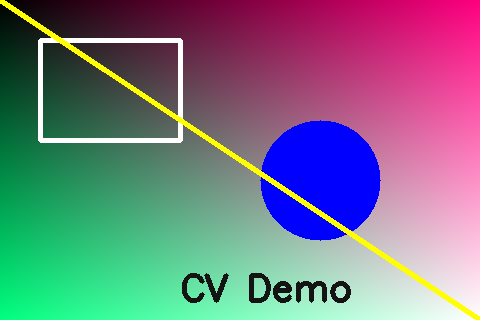

In [7]:
# Abrir con Pillow
pil_img = Image.open("images/sample_rgb.png")
pil_img

In [8]:
print("Formato:", pil_img.format)
print("Modo:", pil_img.mode)
print("Tamaño:", pil_img.size)

Formato: PNG
Modo: RGB
Tamaño: (480, 320)



### Métodos y funciones básicas de Pillow que conviene conocer

- `Image.open(path)` → abrir imagen
- `img.save(path)` → guardar imagen
- `img.size` → tamaño `(width, height)`
- `img.mode` → modo de color (`RGB`, `L`, `RGBA`, ...)
- `img.convert("L")` → convertir a escala de grises
- `img.resize((w, h))` → cambiar tamaño
- `img.crop((x1, y1, x2, y2))` → recortar
- `img.rotate(angulo)` → rotar
- `img.transpose(...)` → flips y rotaciones rápidas
- `ImageOps.mirror(img)` / `ImageOps.flip(img)` → espejado
- `ImageEnhance.Brightness(img)` → brillo
- `ImageEnhance.Contrast(img)` → contraste
- `img.filter(...)` → filtros
- `ImageDraw.Draw(img)` → dibujar
- `np.array(img)` → convertir a NumPy


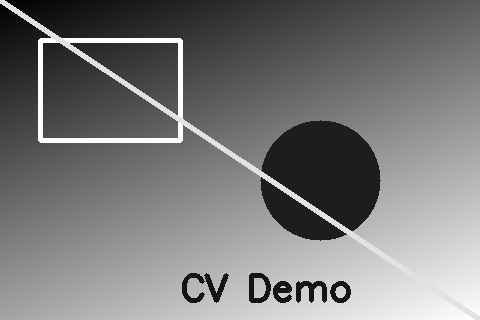

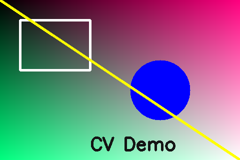

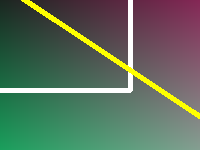

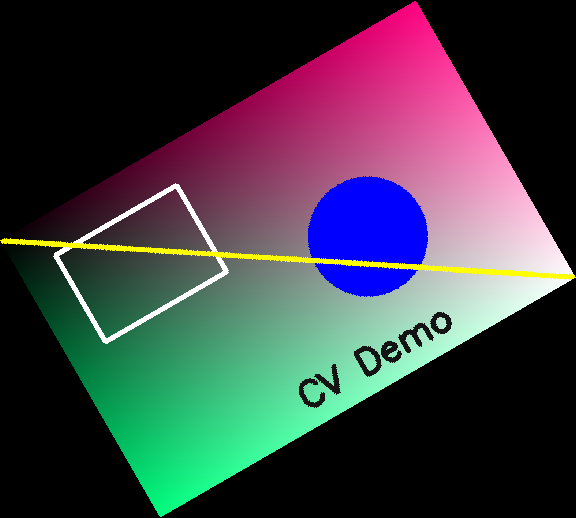

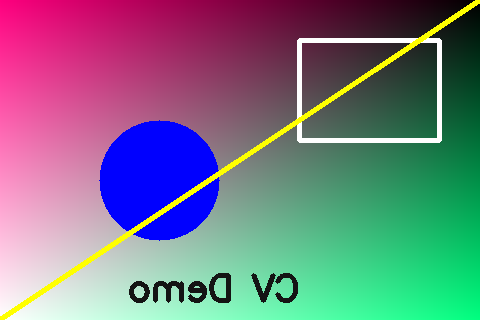

In [9]:

# 1) Convertir a escala de grises
pil_gray = pil_img.convert("L")

# 2) Resize
pil_small = pil_img.resize((240, 160))

# 3) Crop
pil_crop = pil_img.crop((50, 50, 250, 200))

# 4) Rotate
pil_rot = pil_img.rotate(30, expand=True)

# 5) Flip horizontal
pil_mirror = ImageOps.mirror(pil_img)

display(pil_gray)
display(pil_small)
display(pil_crop)
display(pil_rot)
display(pil_mirror)


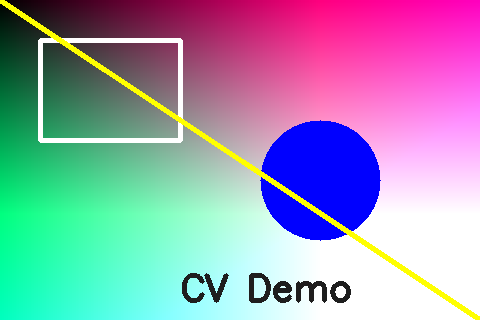

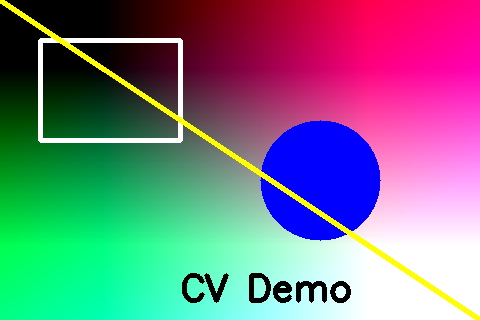

In [10]:
# Brillo
enh_brightness = ImageEnhance.Brightness(pil_img)
pil_brighter = enh_brightness.enhance(1.5)

# Contraste
enh_contrast = ImageEnhance.Contrast(pil_img)
pil_contrast = enh_contrast.enhance(1.8)

display(pil_brighter)
display(pil_contrast)

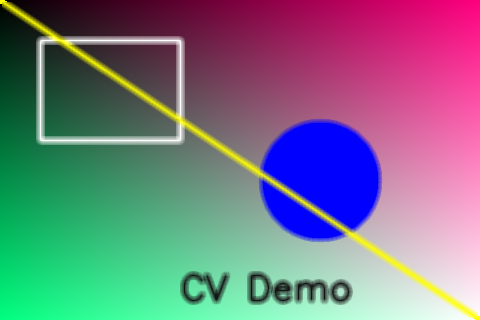

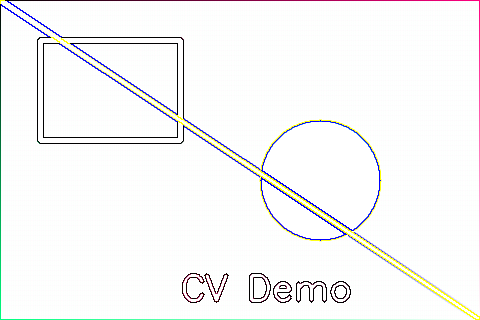

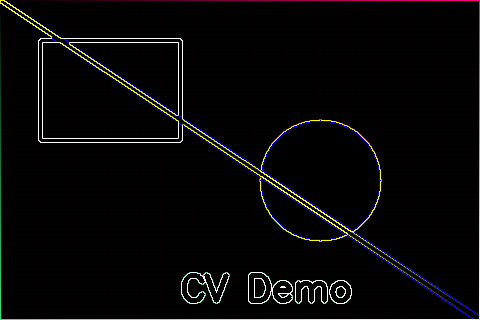

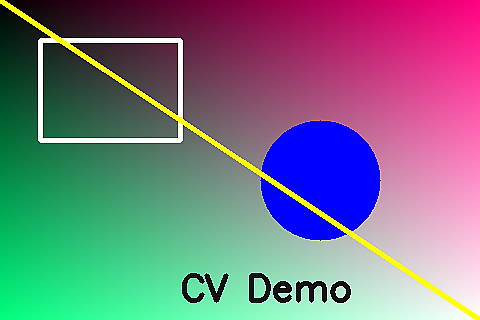

In [11]:
# Algunos filtros típicos
pil_blur = pil_img.filter(ImageFilter.BLUR)
pil_contour = pil_img.filter(ImageFilter.CONTOUR)
pil_edge = pil_img.filter(ImageFilter.FIND_EDGES)
pil_sharp = pil_img.filter(ImageFilter.SHARPEN)

display(pil_blur)
display(pil_contour)
display(pil_edge)
display(pil_sharp)

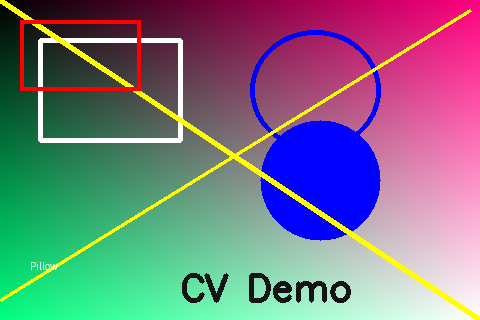

In [12]:
# Dibujar sobre una copia
pil_draw_img = pil_img.copy()
draw = ImageDraw.Draw(pil_draw_img)

draw.rectangle((20, 20, 140, 90), outline="red", width=4)
draw.ellipse((250, 30, 380, 150), outline="blue", width=5)
draw.line((0, 300, 470, 10), fill="yellow", width=3)
draw.text((30, 260), "Pillow", fill="white")

display(pil_draw_img)


In [ ]:

# Convertir una imagen PIL a NumPy
pil_array = np.array(pil_img)

print_basic_info("Array desde Pillow", pil_array)
show_with_matplotlib(pil_array, "Imagen convertida a NumPy")


In [ ]:

# Modificar píxeles directamente con NumPy
edited = pil_array.copy()

# Zona superior izquierda en rojo
edited[0:80, 0:120] = [255, 0, 0]

# Invertir colores en una franja
edited[100:180, 150:330] = 255 - edited[100:180, 150:330]

# Volver a PIL
edited_pil = Image.fromarray(edited)

display(edited_pil)



### Mini resumen de Pillow
Pillow es ideal para:
- tareas rápidas sobre una imagen
- prototipos
- abrir/guardar y transformar
- trabajar de forma intuitiva

Cuando quieres más arsenal de visión por computador clásica, OpenCV entra como un martillo neumático. Con cariño, pero neumático.



## 3. OpenCV: operaciones básicas

OpenCV es especialmente útil para:
- procesamiento clásico
- filtros y transformaciones geométricas
- visión por computador
- vídeo, cámara, tracking, detección, etc.

En OpenCV la imagen suele cargarse en **BGR**, no en RGB.


Imagen OpenCV
  shape: (320, 480, 3)
  dtype: uint8
  min: 0 | max: 255


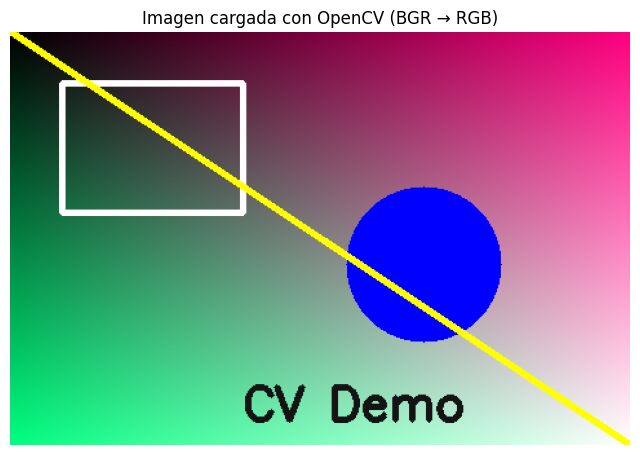

In [13]:

# Abrir con OpenCV
cv_img = cv2.imread("images/sample_rgb.png")

print_basic_info("Imagen OpenCV", cv_img)
show_with_matplotlib(cv_img, "Imagen cargada con OpenCV (BGR → RGB)", is_bgr=True)



### Funciones y métodos básicos de OpenCV que conviene conocer

- `cv2.imread(path)` → abrir imagen
- `cv2.imwrite(path, img)` → guardar imagen
- `cv2.cvtColor(img, code)` → cambiar espacio de color
- `cv2.resize(img, (w, h))` → cambiar tamaño
- `cv2.rotate(img, ...)` → rotaciones rápidas
- `cv2.flip(img, code)` → espejado
- `img[y1:y2, x1:x2]` → crop
- `cv2.GaussianBlur(...)` → desenfoque gaussiano
- `cv2.medianBlur(...)` → desenfoque por mediana
- `cv2.blur(...)` → media
- `cv2.Canny(...)` → detección de bordes
- `cv2.threshold(...)` → umbralización
- `cv2.rectangle(...)`, `cv2.circle(...)`, `cv2.line(...)`, `cv2.putText(...)` → dibujo
- `cv2.split(img)` / `cv2.merge([...])` → separar/unir canales


In [ ]:

# Escala de grises
cv_gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

# Resize
cv_small = cv2.resize(cv_img, (240, 160))

# Crop
cv_crop = cv_img[50:220, 60:260]

# Rotación 90 grados
cv_rot = cv2.rotate(cv_img, cv2.ROTATE_90_CLOCKWISE)

# Flip horizontal
cv_flip = cv2.flip(cv_img, 1)

show_with_matplotlib(cv_gray, "OpenCV - Grises")
show_with_matplotlib(cv_small, "OpenCV - Resize", is_bgr=True)
show_with_matplotlib(cv_crop, "OpenCV - Crop", is_bgr=True)
show_with_matplotlib(cv_rot, "OpenCV - Rotación", is_bgr=True)
show_with_matplotlib(cv_flip, "OpenCV - Flip", is_bgr=True)


In [ ]:

# Separar canales BGR
b, g, r = cv2.split(cv_img)

show_with_matplotlib(b, "Canal B")
show_with_matplotlib(g, "Canal G")
show_with_matplotlib(r, "Canal R")

# Reconstrucción correcta
merged = cv2.merge([b, g, r])
show_with_matplotlib(merged, "Canales unidos", is_bgr=True)


In [ ]:

# Filtros básicos
blur_mean = cv2.blur(cv_gray, (7, 7))
blur_gauss = cv2.GaussianBlur(cv_gray, (7, 7), 0)
blur_median = cv2.medianBlur(cv_gray, 7)

show_with_matplotlib(blur_mean, "Blur media")
show_with_matplotlib(blur_gauss, "Blur gaussiano")
show_with_matplotlib(blur_median, "Blur mediana")


In [ ]:

# Detección de bordes
edges = cv2.Canny(cv_gray, 80, 180)

show_with_matplotlib(cv_gray, "Imagen en gris")
show_with_matplotlib(edges, "Bordes con Canny")


In [ ]:

# Umbralización
_, th_bin = cv2.threshold(cv_gray, 127, 255, cv2.THRESH_BINARY)
_, th_inv = cv2.threshold(cv_gray, 127, 255, cv2.THRESH_BINARY_INV)

show_with_matplotlib(th_bin, "Umbral binario")
show_with_matplotlib(th_inv, "Umbral binario inverso")


In [ ]:

draw_img = cv_img.copy()

cv2.rectangle(draw_img, (30, 30), (180, 100), (0, 255, 0), 3)
cv2.circle(draw_img, (320, 80), 45, (255, 0, 0), 3)
cv2.line(draw_img, (20, 290), (460, 250), (0, 255, 255), 4)
cv2.putText(draw_img, "OpenCV", (180, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

show_with_matplotlib(draw_img, "Dibujo con OpenCV", is_bgr=True)


In [ ]:

# Acceso a píxeles
pixel_bgr = cv_img[100, 100]
print("Pixel en (100,100) [B, G, R]:", pixel_bgr)

# Modificar una zona
pixel_edit = cv_img.copy()
pixel_edit[20:100, 20:180] = [0, 0, 255]  # rojo en BGR

show_with_matplotlib(pixel_edit, "Edición directa sobre el array", is_bgr=True)



## 4. Convertir entre Pillow y OpenCV

Esto es muy útil en prácticas reales.

### Pillow → OpenCV
1. Convertir a `np.array`
2. Pasar de `RGB` a `BGR`

### OpenCV → Pillow
1. Pasar de `BGR` a `RGB`
2. Crear `Image.fromarray(...)`


In [ ]:

# Pillow -> OpenCV
pil_img = Image.open("images/sample_rgb.png").convert("RGB")
pil_to_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

# OpenCV -> Pillow
cv_to_pil = Image.fromarray(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))

print("Pillow -> OpenCV:", type(pil_to_cv), pil_to_cv.shape)
print("OpenCV -> Pillow:", type(cv_to_pil), cv_to_pil.size)

display(cv_to_pil)



## 5. Bloque de pruebas libres para el alumnado

Aquí tienes un pequeño laboratorio para tocar parámetros y ver qué cambia.


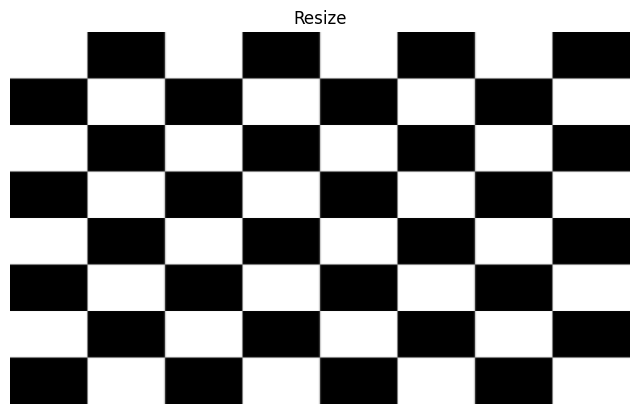

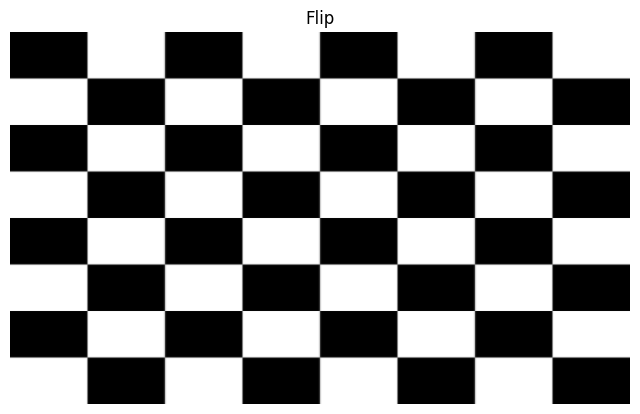

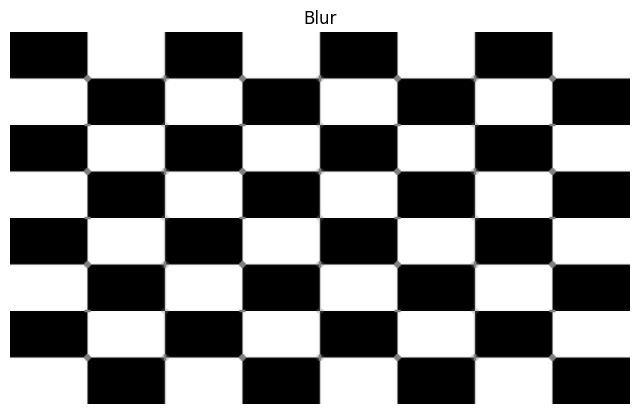

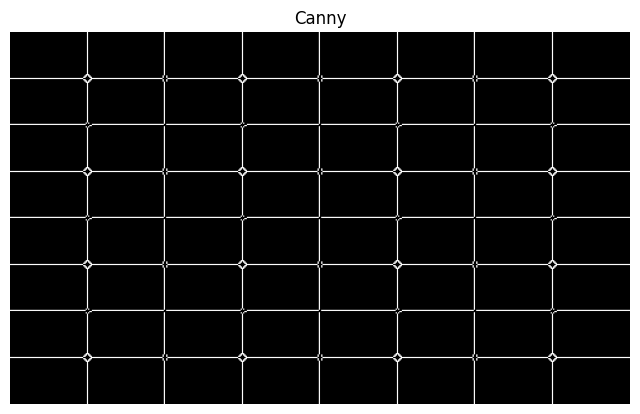

In [14]:

# ========= PRUEBA AQUÍ =========
img = cv2.imread("images/checker.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Cambia estos parámetros
new_size = (500, 300)
flip_code = 1             # 0 vertical, 1 horizontal, -1 ambos
blur_kernel = 5           # debe ser impar para medianBlur
canny1, canny2 = 50, 150

# Transformaciones
resized = cv2.resize(img, new_size)
flipped = cv2.flip(resized, flip_code)
blurred = cv2.medianBlur(cv2.cvtColor(flipped, cv2.COLOR_BGR2GRAY), blur_kernel)
edges = cv2.Canny(blurred, canny1, canny2)

show_with_matplotlib(resized, "Resize", is_bgr=True)
show_with_matplotlib(flipped, "Flip", is_bgr=True)
show_with_matplotlib(blurred, "Blur")
show_with_matplotlib(edges, "Canny")



## 6. Propuestas de ejercicios

### Ejercicios con Pillow
1. Abre una imagen y guárdala en otro formato.
2. Crea una versión en escala de grises.
3. Recorta solo una región de interés.
4. Aumenta el contraste y luego el brillo.
5. Dibuja un rectángulo y un texto sobre la imagen.

### Ejercicios con OpenCV
1. Carga una imagen y conviértela a grises.
2. Aplica `GaussianBlur`, `medianBlur` y `blur`. Compara.
3. Detecta bordes con `Canny`.
4. Aplica una umbralización binaria.
5. Dibuja una bounding box y un texto tipo detector.

### Ejercicios mezclando Pillow + OpenCV
1. Abre con Pillow, convierte a NumPy y procesa con OpenCV.
2. Procesa con OpenCV y vuelve a convertir a Pillow para guardar el resultado.
3. Compara una misma operación en ambas librerías.
